In [1]:
%load_ext autoreload
%autoreload 2

In [28]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from tqdm import tqdm

import sys
sys.path.append("../src")


from geodesiq import *

In [20]:
# ----- Define Hamiltonian and its gradient -----
def ham(z, x):
    return np.array([[z, x],
                     [x, -z]])


hamiltonian = Hamiltonian(ham)

# ----- Set system and control parameters -----
alpha = 2
beta = 2
x = 1
z0 = -10
zf = -z0

hamiltonian.set_parameters(x=x)
hamiltonian.set_control(control_name='z', pulse_initial=z0, pulse_final=zf,
                        initial_state=0, alpha=alpha, beta=beta)

# ----- Solve for optimal pulse -----
hamiltonian.solve_problem(pulse_accuracy=int(1000))

In [21]:
hamiltonian.print_summary()

------------------ Hamiltonian Control Summary ------------------
Hamiltonian: ✅ set
Partial Hamiltonian: ❌ not set
Hamiltonian parameters: x: 1
Control name → z
Pulse initial → -10
Pulse final → 10
Initial state index → 0
Final state index → 0
(Alpha, Beta) → (2, 2)
(Diabatic Alpha, Diabatic Beta) → (❌ not set, ❌ not set)
Eigenproblem solved → ✅ yes
Metric computed → ✅ yes
ODE solved → ✅ yes
---------------------------------------------------------------


In [22]:
gate_fid = Dynamics(duration=50, hamiltonian=hamiltonian).average_gate_fidelity(target_gate=qt.sigmax())
print('Average gate fidelity (at t=tf): ', gate_fid[-1])

Average gate fidelity (at t=tf):  0.977891048276598


In [27]:
dynamics = Dynamics(duration=100, hamiltonian=hamiltonian)

fidelity = dynamics.state_fidelity(c_ops=[])
fidelity_noisy = dynamics.state_fidelity(c_ops=[qt.sigmaz()])
print(fidelity, fidelity_noisy)

0.9999996556418919 0.5000000001118995


# Fidelity sweep for Landau-Zener model

In [40]:
def fidelity_vs_time(durations, hamiltonian, alpha=2, beta=2):

    hamiltonian.set_control(alpha=alpha, beta=beta)
    hamiltonian.solve_problem(pulse_accuracy=int(1000))

    fidelities = []
    for duration in tqdm(durations):
        dynamics = Dynamics(duration=duration, hamiltonian=hamiltonian)
        fidelities.append(dynamics.state_fidelity())

    return np.array(fidelities)

In [51]:
durations = np.linspace(0, 10, 200)
fidelities_geometric = fidelity_vs_time(durations, hamiltonian, alpha=2, beta=2)
fidelities_faquad = fidelity_vs_time(durations, hamiltonian, alpha=4, beta=2)

100%|██████████| 200/200 [00:07<00:00, 27.15it/s]


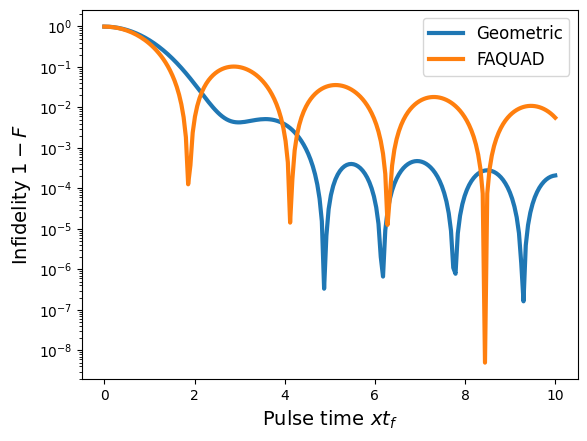

In [53]:
plt.plot(durations, 1-fidelities_geometric, label='Geometric', lw=3)
plt.plot(durations, 1-fidelities_faquad, label='FAQUAD', lw=3)
plt.yscale('log')
plt.ylabel('Infidelity $1-F$', fontsize=14)
plt.xlabel('Pulse time $x t_f$', fontsize=14)
plt.legend(fontsize=12)
plt.show()